In [1]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
data = pd.read_csv("../build/Track_Data/output_data.csv")

In [3]:
data

,xx,yy,zz,time,numbeam,id,particle,En,Ek
0,105.587,0.942049,-0.344924,1.0,1,0,1,99972.100000,99964.900000
1,104.740,-0.366638,1.772140,1.0,1,1,1,33.964800,26.672800
2,106.443,0.366638,-1.772140,1.0,1,2,0,-1.183680,1.183680
3,210.277,8.746880,-0.597174,2.0,1,0,1,98697.500000,98690.200000
4,106.046,-1.442790,2.833400,2.0,1,1,1,19.634000,12.342000
...,...,...,...,...,...,...,...,...,...
21133753,4483.770,1390.520000,765.712000,12962.0,1,1706,0,-0.018108,0.018108
21133754,4483.760,1390.530000,765.728000,12963.0,1,1706,0,-0.018108,0.018108
21133755,4483.740,1390.550000,765.743000,12964.0,1,1706,0,-0.018108,0.018108
21133756,4483.730,1390.540000,765.731000,12965.0,1,1706,0,-0.010950,0.010950


In [5]:
k = 3
result = []
time = []

time_data = data[data['particle'] == 1]['time'].unique()

for i in range(0, len(time_data), 10):
    l = i if i == 0 else i - 1
    subset = data[data['time'] == time_data[l]]
    time.append(time_data[l])

    holes = subset[subset['particle'] == 0][['xx', 'yy', 'zz']].to_numpy()
    electrons = subset[subset['particle'] == 1][['xx', 'yy', 'zz']].to_numpy()

    if len(holes) > 0 and len(electrons) > 0:
        tree = cKDTree(holes)
        distances, indices = tree.query(electrons, k=min(k, len(holes))) 

        if distances.ndim == 1:
            distances = distances[:, np.newaxis]

        sum_r3 = np.sum(distances**3, axis=1)
        inv_mean_r3 = 3.0 / sum_r3 * 10**21

        result.append(inv_mean_r3)

In [ ]:
with open('counts.txt', 'w') as file:
    for i in range(len(time)):
        file.write(str(time[i]))
        for n in range(len(result[i])):
            file.write("\t" + str(result[i][n]))
        file.write("\n")

In [6]:
holes = data[data['particle'] == 0].copy()
hole_idx_max = holes.groupby('id')['time'].idxmax()
hr = holes.loc[hole_idx_max][['xx', 'yy', 'zz']].to_numpy()

electrons = data[data['particle'] == 1].copy()
electron_idx_max = electrons.groupby('id')['time'].idxmax()
er = electrons.loc[electron_idx_max][['xx', 'yy', 'zz']].to_numpy()

In [ ]:
with open('last_hole_coordinates.csv', 'w') as file:
    file.write("x,y,z\n")
    for i in range(len(hr)):
        file.write(str(hr[i][0]) + "," + str(hr[i][1]) + "," + str(hr[i][2]) + "\n")

with open('last_electron_coordinates.csv', 'w') as file:
    file.write("x,y,z\n")
    for i in range(len(er)):
        file.write(str(er[i][0]) + "," + str(er[i][1]) + "," + str(er[i][2]) + "\n")

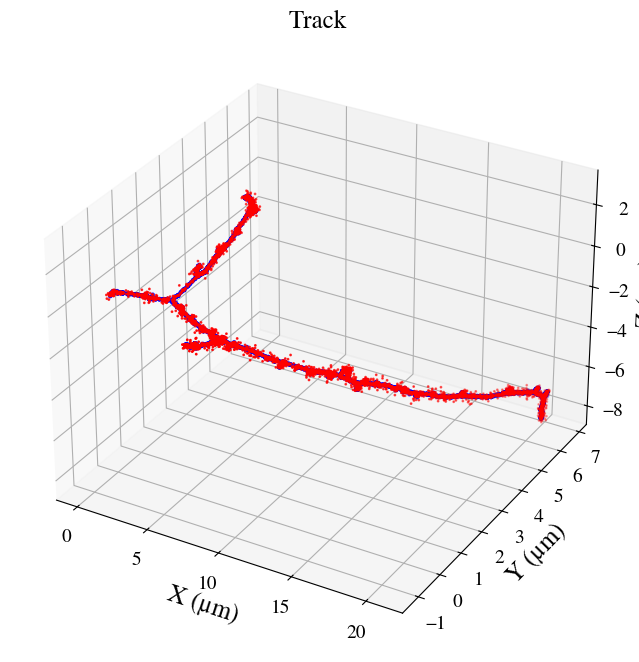

In [7]:
hx = [p[0] * 1e-3 for p in hr]
hy = [p[1] * 1e-3 for p in hr]
hz = [p[2] * 1e-3 for p in hr]

ex = [p[0] * 1e-3 for p in er]
ey = [p[1] * 1e-3 for p in er]
ez = [p[2] * 1e-3 for p in er]

with plt.rc_context({
    'font.family': 'Nimbus Roman',
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Nimbus Roman',
    'mathtext.it': 'Nimbus Roman:italic',
}):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(ex, ey, ez, c='red', marker='o', s=1)
    ax.scatter(hx, hy, hz, c='blue', marker='o', s=5)
    ax.set_xlabel(r'X ($\mathrm{\mu m}$)', fontsize=18)
    ax.set_ylabel(r'Y ($\mathrm{\mu m}$)', fontsize=18)
    ax.set_zlabel(r'Z ($\mathrm{\mu m}$)', fontsize=18)
    ax.set_title('Track', fontsize=18)
    plt.tick_params(axis='both', 
                    which='major', 
                    labelsize=14)
    plt.show()

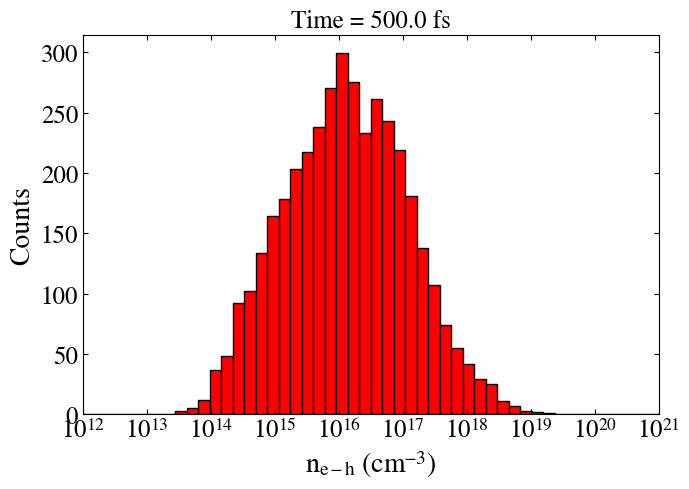

In [8]:
i = 50

bins_log = np.logspace(12, 21, 51)
with plt.rc_context({
    'font.family': 'Nimbus Roman',
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Nimbus Roman',
    'mathtext.it': 'Nimbus Roman:italic',
}):
    plt.figure(figsize=(7, 5))
    plt.hist(result[i], bins=bins_log, edgecolor='black', alpha=1, color="red")
    plt.xlabel(r'$\mathrm{n}_{\mathrm{e-h}}$ ($\mathrm{cm}^{\mathrm{-3}}$)', fontsize=20)
    plt.ylabel('Counts', fontsize=20)
    plt.title(f'Time = {time[i]} fs', fontsize=18)
    plt.tick_params(axis='both', 
                    which='major', 
                    labelsize=18,
                    top=True,
                    bottom=True,
                    left=True,
                    right=True,
                    direction='in')
    plt.xscale('log')
    #plt.yscale('log')
    plt.xlim([1e12, 1e21])
    plt.xticks([1e12, 1e13, 1e14, 1e15, 1e16, 1e17, 1e18, 1e19, 1e20, 1e21]) 
    plt.tight_layout()
    plt.show()